# LiH: Data Efficiency & Feature Importance

1. Data efficiency curves with error bands (5 seeds, 2000 epochs for MLP)
2. Feature importance (impurity-based)

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2

print('All imports OK')

All imports OK


## 1. Load Data and Build Features

In [2]:
ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
N_QUBITS = meta['n_qubits']

backend = FakeJakartaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q = meta['n_2q_gates']
N_SX = meta['n_sx_gates']
ALL_OBS = list(range(1, len(PAULI_LABELS)))

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([qubit_props[q]['T1']*active, qubit_props[q]['T2']*active,
                      qubit_props[q]['readout_error']*active])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        nf = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *nf])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

ideal_test = ideal_data[1800:]
noisy_test = noisy_data[1800:]
X_test, y_test = build_features(noisy_test, ideal_test, ALL_OBS)
baseline_mae = mean_absolute_error(y_test, X_test[:, 0])

print(f'Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'Baseline (unmitigated) MAE: {baseline_mae:.4f}')

Test set: 12200 samples, 33 features
Baseline (unmitigated) MAE: 0.0406


## 2. Data Efficiency Curves (5 seeds)

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_te, y_te, n_epochs=2000, patience=25, seed=42):
    scaler = StandardScaler()
    Xs_tr = scaler.fit_transform(X_tr)
    Xs_te = scaler.transform(X_te)

    torch.manual_seed(seed)
    Xt = torch.tensor(Xs_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    Xv = torch.tensor(Xs_te, dtype=torch.float32)

    model = MLP(X_tr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.HuberLoss()

    best_mae, best_state, no_imp = float('inf'), None, 0
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            mae = mean_absolute_error(y_te, model(Xv).numpy().ravel())
        if mae < best_mae - 1e-6:
            best_mae = mae; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience: break
    return best_mae

train_sizes = [50, 100, 200, 400, 800, 1200, 1800]
n_seeds = 5
rf_results = {n: [] for n in train_sizes}
mlp_results = {n: [] for n in train_sizes}

for seed in range(n_seeds):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(1800)
    for n in train_sizes:
        subset_idx = np.arange(1800) if n == 1800 else perm[:n]
        X_tr, y_tr = build_features(noisy_data[subset_idx], ideal_data[subset_idx], ALL_OBS)

        rf = RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        rf_results[n].append(mean_absolute_error(y_test, rf.predict(X_test)))

        mlp_mae = train_mlp(X_tr, y_tr, X_test, y_test, seed=seed)
        mlp_results[n].append(mlp_mae)
    print(f'  Seed {seed} done')

rf_means = [np.mean(rf_results[n]) for n in train_sizes]
rf_stds = [np.std(rf_results[n]) for n in train_sizes]
mlp_means = [np.mean(mlp_results[n]) for n in train_sizes]
mlp_stds = [np.std(mlp_results[n]) for n in train_sizes]

print(f'\nResults (mean ± std over {n_seeds} seeds):')
print(f'{"n":>6} {"RF":>16} {"MLP":>16}')
print('-' * 40)
for i, n in enumerate(train_sizes):
    print(f'{n:>6} {rf_means[i]:.4f} ± {rf_stds[i]:.4f}  {mlp_means[i]:.4f} ± {mlp_stds[i]:.4f}')

  Seed 0 done
  Seed 1 done
  Seed 2 done
  Seed 3 done
  Seed 4 done

Results (mean ± std over 5 seeds):
     n               RF              MLP
----------------------------------------
    50 0.0148 ± 0.0001  0.0129 ± 0.0002
   100 0.0142 ± 0.0001  0.0125 ± 0.0001
   200 0.0138 ± 0.0001  0.0123 ± 0.0001
   400 0.0136 ± 0.0000  0.0122 ± 0.0001
   800 0.0135 ± 0.0000  0.0121 ± 0.0001
  1200 0.0135 ± 0.0000  0.0121 ± 0.0001
  1800 0.0135 ± 0.0000  0.0121 ± 0.0001


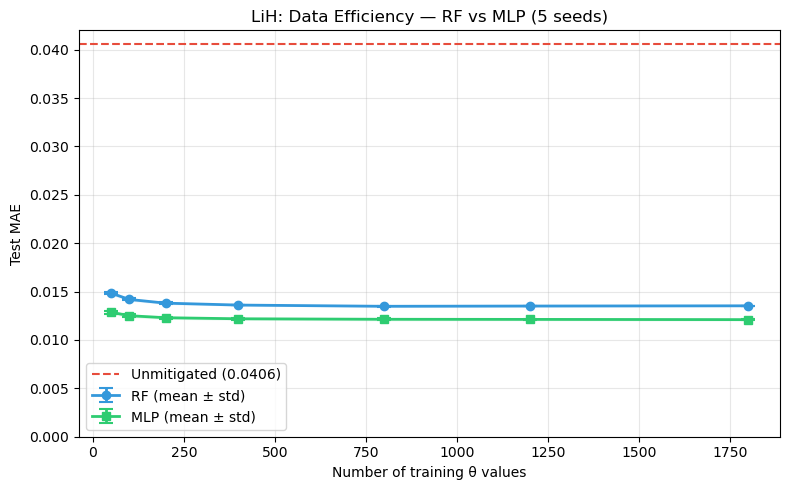

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(train_sizes, rf_means, yerr=rf_stds, fmt='o-', color='#3498db',
            linewidth=2, markersize=6, capsize=5, capthick=1.5, label='RF (mean ± std)')
ax.fill_between(train_sizes, [m-s for m,s in zip(rf_means, rf_stds)],
                [m+s for m,s in zip(rf_means, rf_stds)], color='#3498db', alpha=0.1)

ax.errorbar(train_sizes, mlp_means, yerr=mlp_stds, fmt='s-', color='#2ecc71',
            linewidth=2, markersize=6, capsize=5, capthick=1.5, label='MLP (mean ± std)')
ax.fill_between(train_sizes, [m-s for m,s in zip(mlp_means, mlp_stds)],
                [m+s for m,s in zip(mlp_means, mlp_stds)], color='#2ecc71', alpha=0.1)

ax.axhline(baseline_mae, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Unmitigated ({baseline_mae:.4f})')
ax.set_xlabel('Number of training θ values')
ax.set_ylabel('Test MAE')
ax.set_title('LiH: Data Efficiency — RF vs MLP (5 seeds)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('lih_data_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Importance

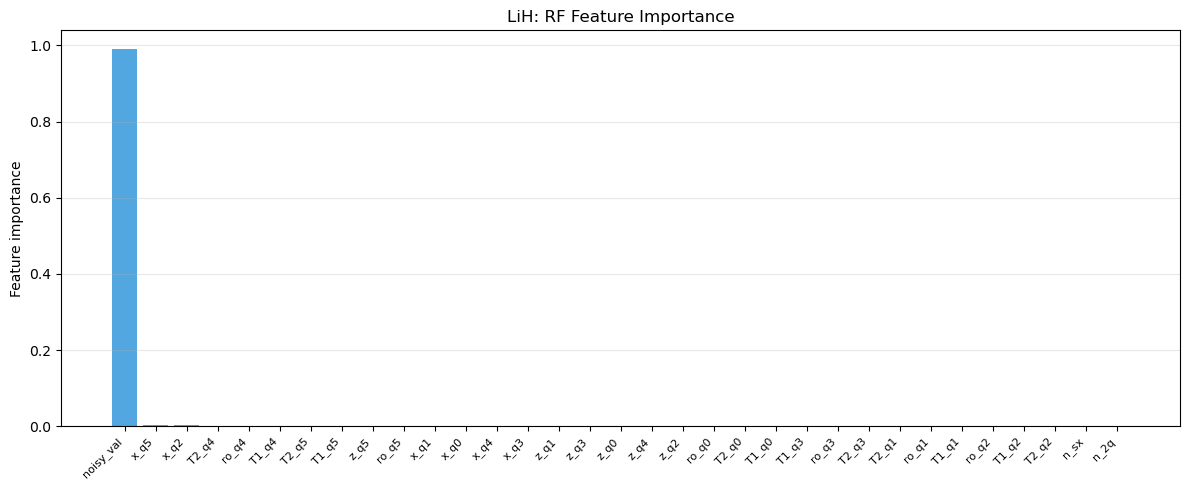


Top 10 features:
  1. noisy_val    0.9899
  2. x_q5         0.0022
  3. x_q2         0.0022
  4. T2_q4        0.0007
  5. ro_q4        0.0006
  6. T1_q4        0.0006
  7. T2_q5        0.0003
  8. T1_q5        0.0003
  9. z_q5         0.0003
  10. ro_q5        0.0003


In [5]:
X_full, y_full = build_features(noisy_data[:1800], ideal_data[:1800], ALL_OBS)
rf_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_full, y_full)

# Build feature names for 6 qubits
feature_names = ['noisy_val']
for q in range(N_QUBITS):
    feature_names.append(f'x_q{q}')
for q in range(N_QUBITS):
    feature_names.append(f'z_q{q}')
feature_names.extend(['n_2q', 'n_sx'])
for q in range(N_QUBITS):
    feature_names.extend([f'T1_q{q}', f'T2_q{q}', f'ro_q{q}'])

importances = rf_full.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(importances)), importances[idx], color='#3498db', alpha=0.85)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in idx], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Feature importance')
ax.set_title('LiH: RF Feature Importance')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lih_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
for rank, i in enumerate(idx[:10]):
    print(f'  {rank+1}. {feature_names[i]:<12} {importances[i]:.4f}')